In [2]:
import pandas as pd

movies = pd.read_csv("tmdb_5000_movies.csv")
credits = pd.read_csv("tmdb_5000_credits.csv")

In [ ]:
df = movies.merge(credits, on="title")
df.head()

In [16]:
import ast

def get_first_actor_info(cast_str):
    cast_list = ast.literal_eval(cast_str)
    if len(cast_list) > 0:
        return pd.Series([cast_list[0]['name'], cast_list[0]['id']])
    return pd.Series([None, None])

df[['lead_actor', 'lead_actor_id']] = df['cast'].apply(get_first_actor_info)
df[['title', 'lead_actor', 'lead_actor_id']].head()

,title,lead_actor,lead_actor_id
0,Avatar,Sam Worthington,65731
1,Pirates of the Caribbean: At World's End,Johnny Depp,85
2,Spectre,Daniel Craig,8784
3,The Dark Knight Rises,Christian Bale,3894
4,John Carter,Taylor Kitsch,60900


In [ ]:
import requests

API_KEY = "API Key"

def get_actor_origin(actor_id):
    url = f"https://api.themoviedb.org/3/person/{actor_id}?api_key={API_KEY}"
    response = requests.get(url)
    
    if response.status_code == 200:
        data = response.json()
        return data.get("place_of_birth")
    else:
        return None

In [42]:
get_actor_origin(df['lead_actor_id'].iloc[0])

'Godalming, Surrey, England, UK'

In [43]:
western_keywords = [
    # USA & similar
    "USA", "United States", "America",
    
    # Canada & Australia
    "Canada", "Australia", "New Zealand",
    
    # UK + Europe (major)
    "UK", "England", "Scotland", "Ireland",
    "France", "Germany", "Italy", "Spain", "Portugal",
    "Netherlands", "Belgium", "Switzerland", "Austria",
    "Sweden", "Norway", "Denmark", "Finland",
    "Poland", "Czech", "Slovakia", "Hungary",
    "Greece", "Romania", "Bulgaria",
    
    # Russia
    "Russia", "Russian"
]

In [44]:
def classify_origin(place):
    if not isinstance(place, str):
        return None
    
    if "Turkey" in place:
        return "Non-Western"
    
    for country in western_keywords:
        if country in place:
            return "Western"
    
    return "Non-Western"

In [45]:
sample = df[['lead_actor', 'lead_actor_id']].head(5).copy()
sample['origin_raw'] = sample['lead_actor_id'].apply(get_actor_origin)
sample

,lead_actor,lead_actor_id,origin_raw
0,Sam Worthington,65731,"Godalming, Surrey, England, UK"
1,Johnny Depp,85,"Owensboro, Kentucky, USA"
2,Daniel Craig,8784,"Chester, Cheshire, England, UK"
3,Christian Bale,3894,"Haverfordwest, Pembrokeshire, Wales, UK"
4,Taylor Kitsch,60900,"Kelowna, British Columbia, Canada"


In [46]:
sample['origin'] = sample['origin_raw'].apply(classify_origin)
sample

,lead_actor,lead_actor_id,origin_raw,origin
0,Sam Worthington,65731,"Godalming, Surrey, England, UK",Western
1,Johnny Depp,85,"Owensboro, Kentucky, USA",Western
2,Daniel Craig,8784,"Chester, Cheshire, England, UK",Western
3,Christian Bale,3894,"Haverfordwest, Pembrokeshire, Wales, UK",Western
4,Taylor Kitsch,60900,"Kelowna, British Columbia, Canada",Western


In [47]:
unique_actors = df[['lead_actor', 'lead_actor_id']].drop_duplicates()

In [48]:
unique_actors.head()
len(unique_actors)

1301

In [49]:
unique_actors['origin_raw'] = unique_actors['lead_actor_id'].apply(get_actor_origin)

In [54]:
unique_actors.head()

,lead_actor,lead_actor_id,origin_raw,origin
0,Sam Worthington,65731,"Godalming, Surrey, England, UK",Western
1,Johnny Depp,85,"Owensboro, Kentucky, USA",Western
2,Daniel Craig,8784,"Chester, Cheshire, England, UK",Western
3,Christian Bale,3894,"Haverfordwest, Pembrokeshire, Wales, UK",Western
4,Taylor Kitsch,60900,"Kelowna, British Columbia, Canada",Western


In [52]:
unique_actors['origin'] = unique_actors['origin_raw'].apply(classify_origin)

In [53]:
unique_actors['origin'].value_counts(dropna=False)

origin
Western        1166
Non-Western     109
NaN              26
Name: count, dtype: int64

In [55]:
df = df.merge(unique_actors[['lead_actor_id', 'origin']], 
              on='lead_actor_id', 
              how='left')

In [56]:
df['origin'].value_counts(dropna=False)

origin
Western        3020
Non-Western     184
NaN              26
Name: count, dtype: int64

In [57]:
df = df.dropna(subset=['origin'])

In [ ]:
#have the data set now compare budget rating blah blah blah

In [58]:
df.groupby('origin')['budget'].mean()

origin
Non-Western    2.752989e+07
Western        4.169387e+07
Name: budget, dtype: float64

In [59]:
df.groupby('origin')['vote_average'].mean()

origin
Non-Western    6.527717
Western        6.297682
Name: vote_average, dtype: float64

In [60]:
df.groupby('origin')['popularity'].mean()

origin
Non-Western    22.487999
Western        29.626293
Name: popularity, dtype: float64

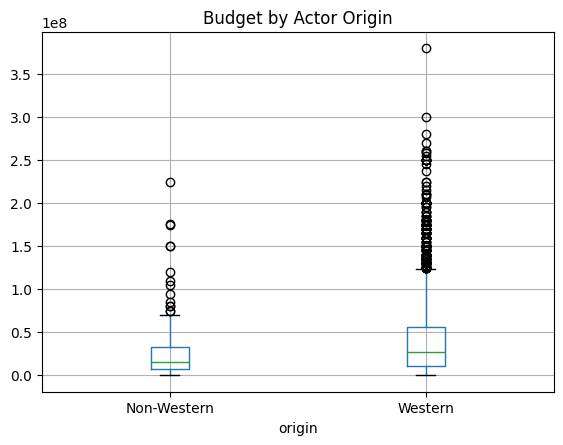

In [61]:
import matplotlib.pyplot as plt

df.boxplot(column='budget', by='origin')
plt.title("Budget by Actor Origin")
plt.suptitle("")
plt.show()

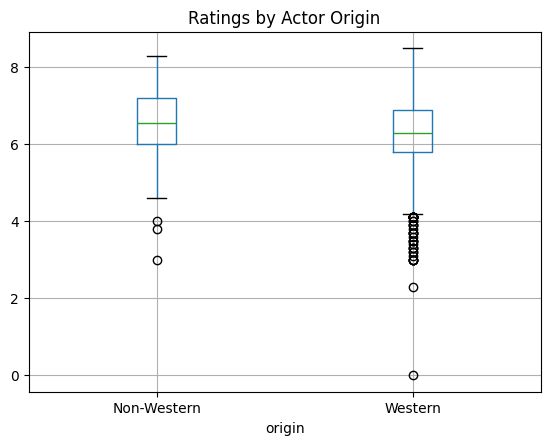

In [62]:
df.boxplot(column='vote_average', by='origin')
plt.title("Ratings by Actor Origin")
plt.suptitle("")
plt.show()

In [ ]:
#the data is done EDA is done now we do hypothesis testing

In [64]:
from scipy.stats import ttest_ind

western = df[df['origin'] == 'Western']['budget']
non_western = df[df['origin'] == 'Non-Western']['budget']

ttest_ind(western, non_western, equal_var=False)

TtestResult(statistic=np.float64(5.337178274219296), pvalue=np.float64(2.3178330449312942e-07), df=np.float64(222.98694048985251))

In [ ]:
#There is a statistically significant difference in movie budgets between Western and Non-Western lead actors. Reject Hypothseis

In [65]:
ttest_ind(
    df[df['origin']=='Western']['vote_average'],
    df[df['origin']=='Non-Western']['vote_average'],
    equal_var=False
)

TtestResult(statistic=np.float64(-3.4414999464725273), pvalue=np.float64(0.0007010107229543657), df=np.float64(205.04261861884063))

In [ ]:
#Non western movies have higher ratings

In [66]:
ttest_ind(
    df[df['origin']=='Western']['popularity'],
    df[df['origin']=='Non-Western']['popularity'],
    equal_var=False
)

TtestResult(statistic=np.float64(4.0292683613292395), pvalue=np.float64(7.43824522697007e-05), df=np.float64(248.8469456978653))

In [ ]:
#Western movies are more popular